# Ejercicio 5: Espacio Vectorial

## Objetivo de la práctica
- Implementar un Sistema de Recuperación de Información completo, desde la lectura del corpus hasta la recuperación de resultados.

## Parte 0: Carga del Corpus

Vamos a utilizar la API de Kaggle para acceder al dataset _Wikipedia Text Corpus for NLP and LLM Projects_

El corpus está disponible desde este [link](https://www.kaggle.com/datasets/gzdekzlkaya/wikipedia-text-corpus-for-nlp-and-llm-projects?utm_source=chatgpt.com)

### Actividad

1. Carga el corpus
2. Realiza las etapas de preprocesamiento sobre el corpus


In [2]:
!pip install kagglehub
!pip install nltk scikit-learn rank-bm25 pandas

import kagglehub
import pandas as pd
import nltk
import re
import os
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

# Descargar recursos de NLTK
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

# Descargar el dataset
path = kagglehub.dataset_download("gzdekzlkaya/wikipedia-text-corpus-for-nlp-and-llm-projects")
print("Path to dataset files:", path)

# Cargar el archivo CSV (asumiendo que hay un archivo CSV en el dataset)
# Primero, listamos los archivos
files = os.listdir(path)
print("Archivos disponibles:", files)

# Buscar archivo CSV
csv_files = [f for f in files if f.endswith('.csv')]
if csv_files:
    df = pd.read_csv(os.path.join(path, csv_files[0]))
    print(f"Dataset cargado con {len(df)} documentos")
    print(df.head())
else:
    print("No se encontró archivo CSV. Verificando otros formatos...")
    # Si hay JSON u otro formato, ajustar aquí
    print("Contenido del directorio:", files)

     ---------------------------------------- 0.0/40.1 kB ? eta -:--:--
     ---------------------------------------- 0.0/40.1 kB ? eta -:--:--
     ---------------------------------------- 0.0/40.1 kB ? eta -:--:--
     ---------------------------------------- 0.0/40.1 kB ? eta -:--:--
     ---------------------------------------- 0.0/40.1 kB ? eta -:--:--
     ---------------------------------------- 0.0/40.1 kB ? eta -:--:--
     ---------------------------------------- 0.0/40.1 kB ? eta -:--:--
     ---------------------------------------- 0.0/40.1 kB ? eta -:--:--
     ---------------------------------------- 0.0/40.1 kB ? eta -:--:--
     ---------------------------------------- 0.0/40.1 kB ? eta -:--:--
     ---------------------------------------- 0.0/40.1 kB ? eta -:--:--
     ---------------------------------------- 0.0/40.1 kB ? eta -:--:--
     ---------------------------------------- 0.0/40.1 kB ? eta -:--:--
     ---------------------------------------- 0.0/40.1 kB ? eta 


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\ASUS\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\ASUS\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


100%|██████████| 18.7M/18.7M [09:48<00:00, 33.2kB/s]

Extracting files...


Path to dataset files: C:\Users\ASUS\.cache\kagglehub\datasets\gzdekzlkaya\wikipedia-text-corpus-for-nlp-and-llm-projects\versions\1
Archivos disponibles: ['wikipedia_text_corpus.csv']
Dataset cargado con 10859 documentos
   Unnamed: 0                                               text
0           1  Anovo\n\nAnovo (formerly A Novo) is a computer...
1           2  Battery indicator\n\nA battery indicator (also...
2           3  Bob Pease\n\nRobert Allen Pease (August 22, 19...
3           4  CAVNET\n\nCAVNET was a secure military forum w...
4           5  CLidar\n\nThe CLidar is a scientific instrumen...


## Procesar el Dataset

In [ ]:
# Preprocesamiento del corpus
def preprocess_text(text):
    """
    Función para preprocesar texto:
    - Convertir a minúsculas
    - Eliminar caracteres especiales y números
    - Tokenizar
    - Eliminar stopwords
    - Aplicar stemming
    """
    if not isinstance(text, str):
        return ""
    
    # Convertir a minúsculas
    text = text.lower()
    
    # Eliminar caracteres especiales y números (solo letras y espacios)
    text = re.sub(r'[^a-záéíóúñ\s]', '', text)
    
    # Tokenizar
    tokens = word_tokenize(text, language='spanish')
    
    # Cargar stopwords en español
    stop_words = set(stopwords.words('spanish'))
    
    # Stemmer
    stemmer = PorterStemmer()
    
    # Filtrar stopwords y aplicar stemming
    tokens = [stemmer.stem(token) for token in tokens if token not in stop_words and len(token) > 2]
    
    return ' '.join(tokens)

# Aplicar preprocesamiento a los documentos
text_column = None
for col in df.columns:
    if 'text' in col.lower() or 'content' in col.lower() or 'article' in col.lower():
        text_column = col
        break

if text_column:
    print(f"Procesando columna: {text_column}")
    df['processed_text'] = df[text_column].apply(preprocess_text)
    # Eliminar documentos vacíos
    df = df[df['processed_text'].str.strip() != '']
    print(f"Documentos después de preprocesamiento: {len(df)}")
else:
    print("No se encontró columna de texto. Usando primera columna de tipo string")
    # Buscar primera columna de tipo string
    for col in df.columns:
        if df[col].dtype == 'object':
            text_column = col
            break
    df['processed_text'] = df[text_column].apply(preprocess_text)
    df = df[df['processed_text'].str.strip() != '']

Procesando columna: text
Documentos después de preprocesamiento: 10859


## Parte 1: Recuperación con TF-IDF

### Actividad:
3. Obtén la representación vectorial de los documentos utilizando el modelo TF-IDF
4. A partir de un conjunto de 10 queries, verifica la recuperación del sistema

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Crear matriz TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)  # Limitar a 5000 características
tfidf_matrix = vectorizer.fit_transform(df['processed_text'])
print(f"Matriz TF-IDF creada: {tfidf_matrix.shape}")

# Definir 10 queries de ejemplo sobre temas variados
queries = [
    "inteligencia artificial y machine learning",
    "cambio climático y calentamiento global",
    "segunda guerra mundial hitler",
    "tecnología blockchain y criptomonedas",
    "fútbol mundialista messi",
    "medicina y vacunas contra el covid",
    "programación python lenguaje computadoras",
    "economía inflación crisis financiera",
    "filosofía platón aristóteles",
    "música rock and roll beatles"
]

# Función para buscar documentos similares a una query
def search_tfidf(query, top_k=5):
    # Preprocesar query
    processed_query = preprocess_text(query)
    
    # Transformar query al espacio TF-IDF
    query_vec = vectorizer.transform([processed_query])
    
    # Calcular similitud coseno
    similarities = cosine_similarity(query_vec, tfidf_matrix).flatten()
    
    # Obtener índices de documentos más similares
    top_indices = similarities.argsort()[-top_k:][::-1]
    
    results = []
    for idx in top_indices:
        if similarities[idx] > 0:
            results.append({
                'rank': len(results) + 1,
                'document_id': idx,
                'score': similarities[idx],
                'text_preview': df.iloc[idx][text_column][:200] if text_column else df.iloc[idx]['processed_text'][:200]
            })
    
    return results

# Probar con las queries
print("=" * 80)
print("RESULTADOS CON TF-IDF")
print("=" * 80)

for i, query in enumerate(queries, 1):
    print(f"\nQuery {i}: {query}")
    results = search_tfidf(query, top_k=3)
    if results:
        for r in results:
            print(f"  {r['rank']}. Score: {r['score']:.4f} - {r['text_preview']}...")
    else:
        print("  No se encontraron resultados")

Matriz TF-IDF creada: (10859, 5000)
RESULTADOS CON TF-IDF

Query 1: inteligencia artificial y machine learning
  1. Score: 0.7364 - Outline of machine learning

The following outline is provided as an overview of and topical guide to machine learning. Machine learning is a subfield of soft computing within computer science that ev...
  2. Score: 0.4644 - Teaching machine

Teaching machines were originally mechanical devices. They presented educational materials and taught students. They were first invented by Sidney L. Pressey in the mid-1920s. His ma...
  3. Score: 0.4391 - Digital learning

Digital learning is any type of learning that is accompanied by technology or by instructional practice that makes effective use of technology. It encompasses the application of a wi...

Query 2: cambio climático y calentamiento global
  1. Score: 0.6308 - Global information system

There are a variety of definitions and understandings of a global information system (GIS, GLIS), such as 


Common 

## Parte 2: Recuperación con BM25

### Actividad:
5. Implementa un sistema de recuperación usando el modelo BM25.
6. Para el mismo conjunto de 10 queries, verifica la recuperación del sistema

In [5]:
from rank_bm25 import BM25Okapi

# Preparar documentos tokenizados para BM25
tokenized_docs = [doc.split() for doc in df['processed_text']]
bm25 = BM25Okapi(tokenized_docs)
print("Modelo BM25 creado exitosamente")

# Función para buscar con BM25
def search_bm25(query, top_k=5):
    # Preprocesar query
    processed_query = preprocess_text(query)
    tokenized_query = processed_query.split()
    
    # Obtener scores BM25
    scores = bm25.get_scores(tokenized_query)
    
    # Obtener top_k documentos
    top_indices = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:top_k]
    
    results = []
    for idx in top_indices:
        if scores[idx] > 0:
            results.append({
                'rank': len(results) + 1,
                'document_id': idx,
                'score': scores[idx],
                'text_preview': df.iloc[idx][text_column][:200] if text_column else df.iloc[idx]['processed_text'][:200]
            })
    
    return results

# Probar BM25 con las mismas queries
print("=" * 80)
print("RESULTADOS CON BM25")
print("=" * 80)

bm25_results = []
for i, query in enumerate(queries, 1):
    print(f"\nQuery {i}: {query}")
    results = search_bm25(query, top_k=3)
    bm25_results.append(results)
    if results:
        for r in results:
            print(f"  {r['rank']}. Score: {r['score']:.4f} - {r['text_preview']}...")
    else:
        print("  No se encontraron resultados")

Modelo BM25 creado exitosamente
RESULTADOS CON BM25

Query 1: inteligencia artificial y machine learning
  1. Score: 17.1832 - Outline of machine learning

The following outline is provided as an overview of and topical guide to machine learning. Machine learning is a subfield of soft computing within computer science that ev...
  2. Score: 14.5589 - Ryszard S. Michalski

Ryszard S. Michalski (May 7, 1937 â€“ September 20, 2007) was a Polish-American computer scientist. Michalski was Professor at George Mason University and a pioneer in the field ...
  3. Score: 13.9446 - DoceboLMS

Docebo is a software as a service artificial intelligence platform for e-learning, also known as a learning management system. Established in 2005, Docebo (Latin for "I will teach") offers ...

Query 2: cambio climático y calentamiento global
  1. Score: 5.2191 - Global information system

There are a variety of definitions and understandings of a global information system (GIS, GLIS), such as 


Common to 

## Parte 3: Comparación de resultados

### Actividad:
7. Verifica cuáles documentos son recuperados (y en qué orden) por cada modelo de recuperación 

In [6]:
# Comparar resultados entre TF-IDF y BM25
print("=" * 80)
print("COMPARACIÓN DE MODELOS")
print("=" * 80)

comparison_data = []

for i, query in enumerate(queries):
    tfidf_res = search_tfidf(query, top_k=5)
    bm25_res = search_bm25(query, top_k=5)
    
    tfidf_ids = [r['document_id'] for r in tfidf_res]
    bm25_ids = [r['document_id'] for r in bm25_res]
    
    # Documentos comunes
    common_docs = set(tfidf_ids) & set(bm25_ids)
    
    comparison_data.append({
        'query': query,
        'tfidf_top_docs': tfidf_ids,
        'bm25_top_docs': bm25_ids,
        'common_docs': list(common_docs),
        'overlap_percentage': (len(common_docs) / 5) * 100 if tfidf_ids else 0
    })
    
    print(f"\nQuery {i+1}: {query}")
    print(f"  Coincidencia entre TF-IDF y BM25: {len(common_docs)}/5 documentos ({comparison_data[-1]['overlap_percentage']:.0f}%)")
    print(f"  Documentos compartidos IDs: {common_docs if common_docs else 'Ninguno'}")

# Análisis adicional de relevancia
print("\n" + "=" * 80)
print("ANÁLISIS DE CONSISTENCIA ENTRE MODELOS")
print("=" * 80)

avg_overlap = np.mean([d['overlap_percentage'] for d in comparison_data])
print(f"Promedio de coincidencia entre modelos: {avg_overlap:.2f}%")

# Mostrar ejemplo detallado de la primera query
print("\n" + "=" * 80)
print("EJEMPLO DETALLADO - Primera Query")
print("=" * 80)
print(f"Query: {queries[0]}")
print("\n--- TF-IDF ---")
tfidf_example = search_tfidf(queries[0], top_k=3)
for r in tfidf_example:
    print(f"\nRank {r['rank']} (Score: {r['score']:.4f})")
    print(f"Texto: {r['text_preview']}...")

print("\n--- BM25 ---")
bm25_example = search_bm25(queries[0], top_k=3)
for r in bm25_example:
    print(f"\nRank {r['rank']} (Score: {r['score']:.4f})")
    print(f"Texto: {r['text_preview']}...")

COMPARACIÓN DE MODELOS

Query 1: inteligencia artificial y machine learning
  Coincidencia entre TF-IDF y BM25: 3/5 documentos (60%)
  Documentos compartidos IDs: {10547, 9538, 10699}

Query 2: cambio climático y calentamiento global
  Coincidencia entre TF-IDF y BM25: 4/5 documentos (80%)
  Documentos compartidos IDs: {1608, 1750, 7366, 311}

Query 3: segunda guerra mundial hitler
  Coincidencia entre TF-IDF y BM25: 0/5 documentos (0%)
  Documentos compartidos IDs: Ninguno

Query 4: tecnología blockchain y criptomonedas
  Coincidencia entre TF-IDF y BM25: 0/5 documentos (0%)
  Documentos compartidos IDs: Ninguno

Query 5: fútbol mundialista messi
  Coincidencia entre TF-IDF y BM25: 0/5 documentos (0%)
  Documentos compartidos IDs: Ninguno

Query 6: medicina y vacunas contra el covid
  Coincidencia entre TF-IDF y BM25: 0/5 documentos (0%)
  Documentos compartidos IDs: Ninguno

Query 7: programación python lenguaje computadoras
  Coincidencia entre TF-IDF y BM25: 0/5 documentos (0%)
  D

## Comparacion de resultados 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import seaborn as sns

# Configurar estilo de las gráficas
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# Colores personalizadosb
COLOR_TFIDF = '#3498db'  # Azul
COLOR_BM25 = '#e74c3c'   # Rojo
COLOR_COMMON = '#2ecc71' # Verde

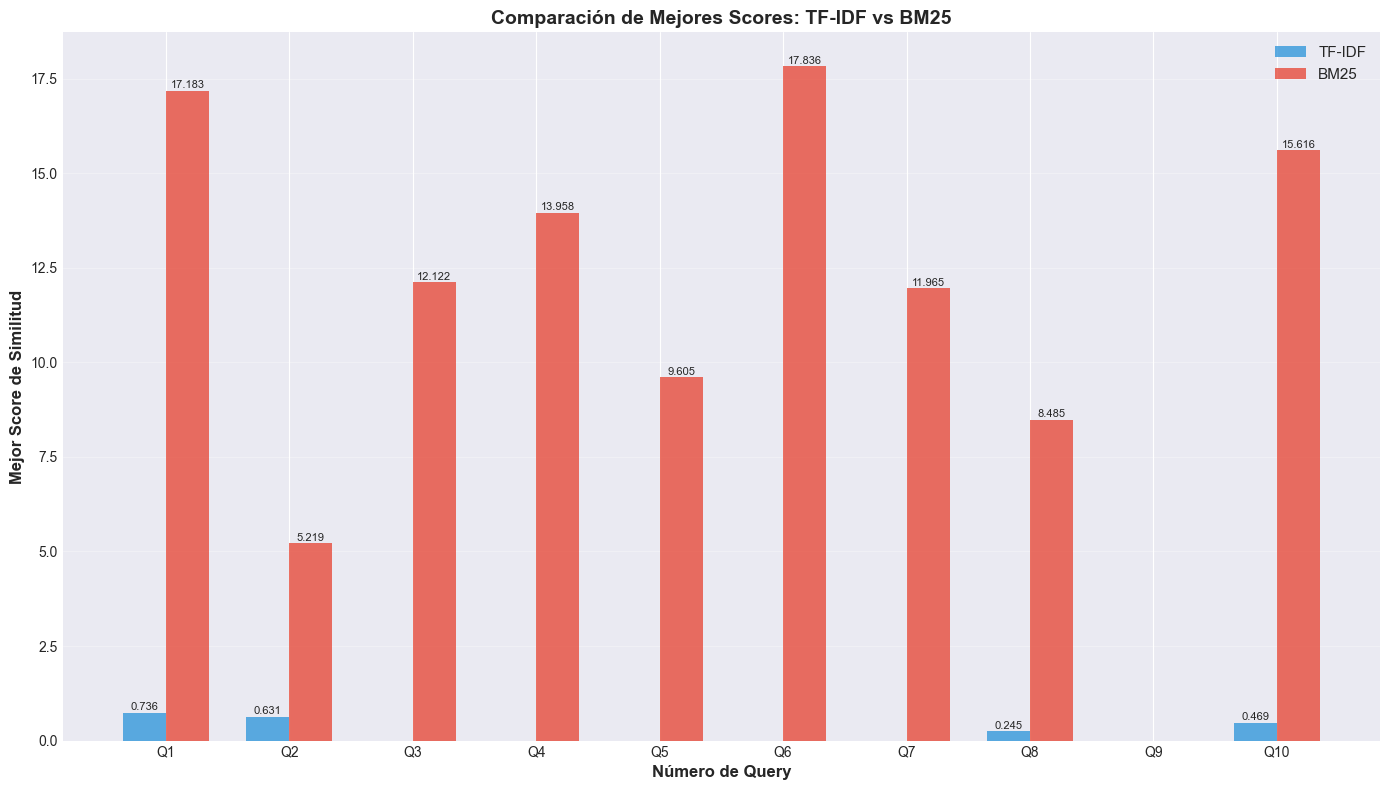

In [8]:
def plot_scores_comparison(queries, tfidf_scores_list, bm25_scores_list):
    """
    Gráfica de barras comparando los mejores scores de cada modelo por query
    """
    fig, ax = plt.subplots(figsize=(14, 8))
    
    x = np.arange(len(queries))
    width = 0.35
    
    # Obtener el mejor score de cada query para cada modelo
    tfidf_best = [max(scores) if scores else 0 for scores in tfidf_scores_list]
    bm25_best = [max(scores) if scores else 0 for scores in bm25_scores_list]
    
    bars1 = ax.bar(x - width/2, tfidf_best, width, label='TF-IDF', 
                   color=COLOR_TFIDF, alpha=0.8)
    bars2 = ax.bar(x + width/2, bm25_best, width, label='BM25', 
                   color=COLOR_BM25, alpha=0.8)
    
    ax.set_xlabel('Número de Query', fontsize=12, fontweight='bold')
    ax.set_ylabel('Mejor Score de Similitud', fontsize=12, fontweight='bold')
    ax.set_title('Comparación de Mejores Scores: TF-IDF vs BM25', 
                 fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'Q{i+1}' for i in range(len(queries))])
    ax.legend(loc='upper right', fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Agregar valores en las barras
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                       f'{height:.3f}', ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.show()

# Recolectar scores para las gráficas
tfidf_scores_list = []
bm25_scores_list = []

for i, query in enumerate(queries):
    tfidf_res = search_tfidf(query, top_k=5)
    bm25_res = search_bm25(query, top_k=5)
    
    tfidf_scores_list.append([r['score'] for r in tfidf_res])
    bm25_scores_list.append([r['score'] for r in bm25_res])

plot_scores_comparison(queries, tfidf_scores_list, bm25_scores_list)

## Para que la compraracion sea eficaz:
se debe normalizar 


In [9]:
def max_normalize(scores_list):
    """
    Normaliza dividiendo por el máximo valor
    """
    max_score = max(scores_list) if scores_list else 1
    return [s / max_score for s in scores_list]